In [1]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yaml

# from scipy.optimize import curve_fit

from pmt.fitresults import *

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})


In [2]:
# load files
fit_res_dir = Path("plots/260706/fit/fit_results")

files = sorted(fit_res_dir.glob("*led100_poisson.yaml"))
df_poisson = pd.DataFrame([load_fit_yaml(f) for f in files])

files = sorted(fit_res_dir.glob("*led100_bellamy.yaml"))
df_bellamy = pd.DataFrame([load_fit_yaml(f) for f in files])

# df_bellamy


# Gain

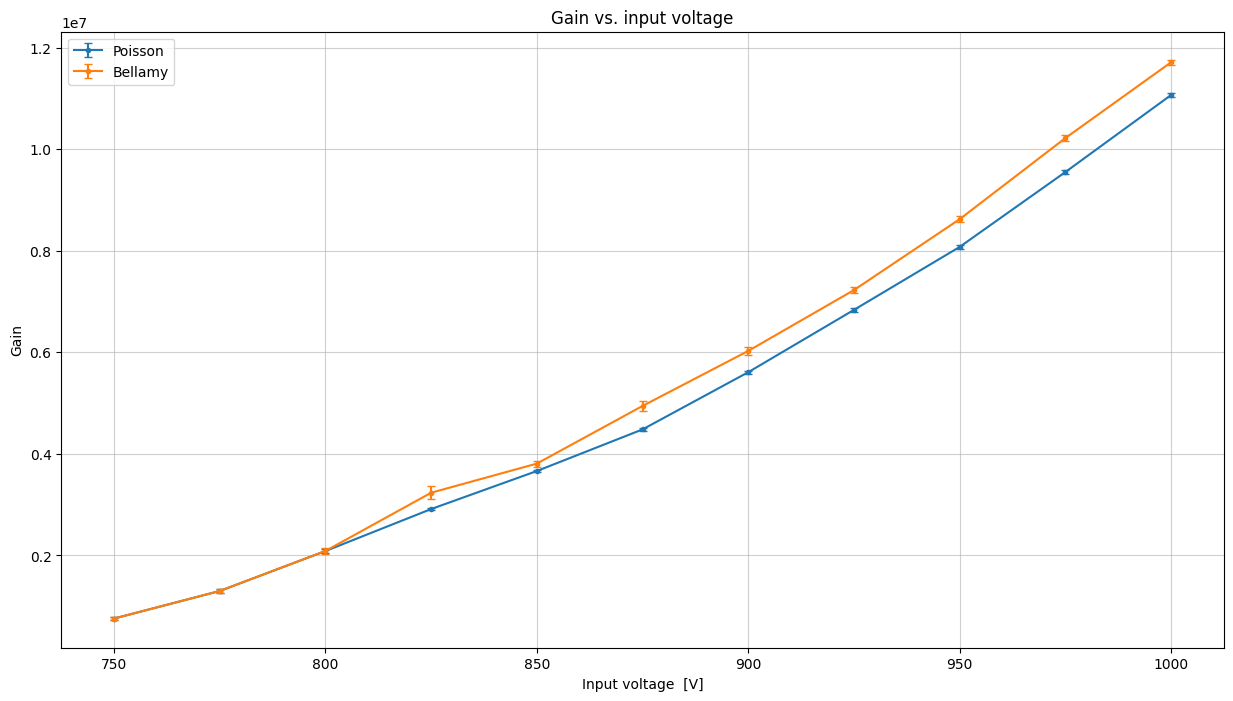

In [3]:
fig, axes = plt.subplots(1, 1, figsize=(15, 8))

xtitle = "Input voltage  [V]"
ytitle = "Gain"
title = "Gain vs. input voltage"
plot_parameter( df_poisson, "gain", ax=axes, x="HV", xlabel=xtitle, ylabel=ytitle, title=title, label="Poisson", fmt='o-', markersize=3);
plot_parameter( df_bellamy, "gain", ax=axes, x="HV", xlabel=xtitle, ylabel=ytitle, title=title, label="Bellamy", fmt='o-', markersize=3);

# Fit parameters

## Poisson vs Bellamy

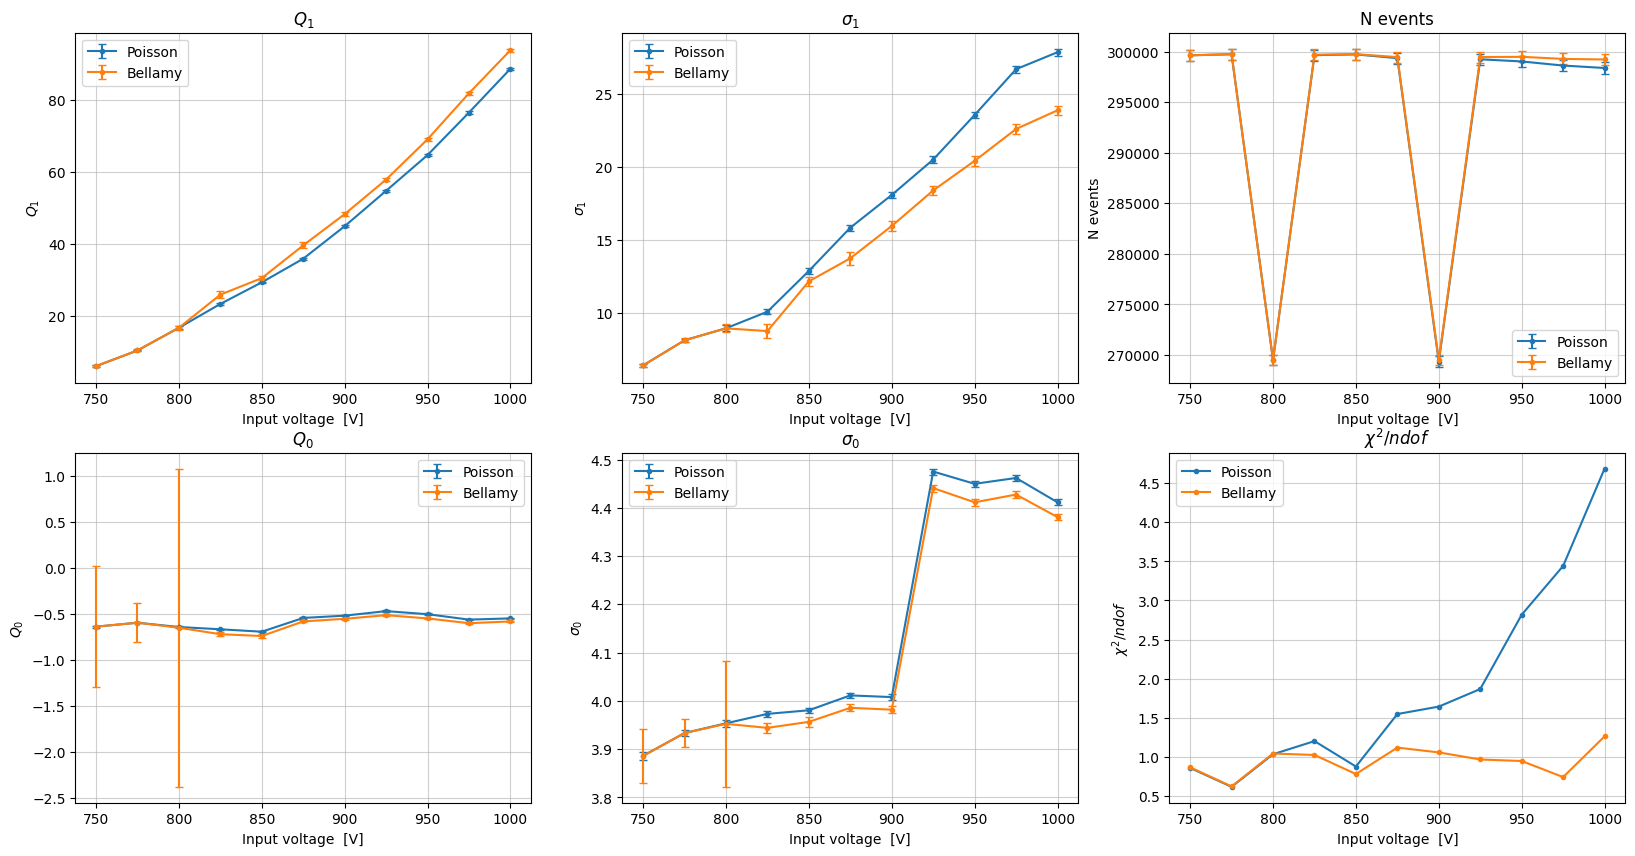

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()

xtitle = "Input voltage  [V]"
formt = 'o-'

bounds_poisson = False
bounds_bellamy = False


parms = ["q1_mV_ns", "sigma1_mV_ns", "n_total", "q0_mV_ns", "sigma0_mV_ns", "chi2_ndof"]
ytitles = [r"$Q_1$", r"$\sigma_1$", r"N events", r"$Q_0$", r"$\sigma_0$", r"$\chi^2 / ndof$"]

i = 0
for par, ytitle in zip(parms, ytitles):
    title = ytitle
    plot_parameter( df_poisson, par, ax=axes[i], x="HV", xlabel=xtitle, ylabel=ytitle, title=title, label="Poisson", show_bounds=bounds_poisson, fmt=formt, markersize=3)
    plot_parameter( df_bellamy, par, ax=axes[i], x="HV", xlabel=xtitle, ylabel=ytitle, title=title, label="Bellamy", show_bounds=bounds_bellamy, fmt=formt, markersize=3)
    i+=1;



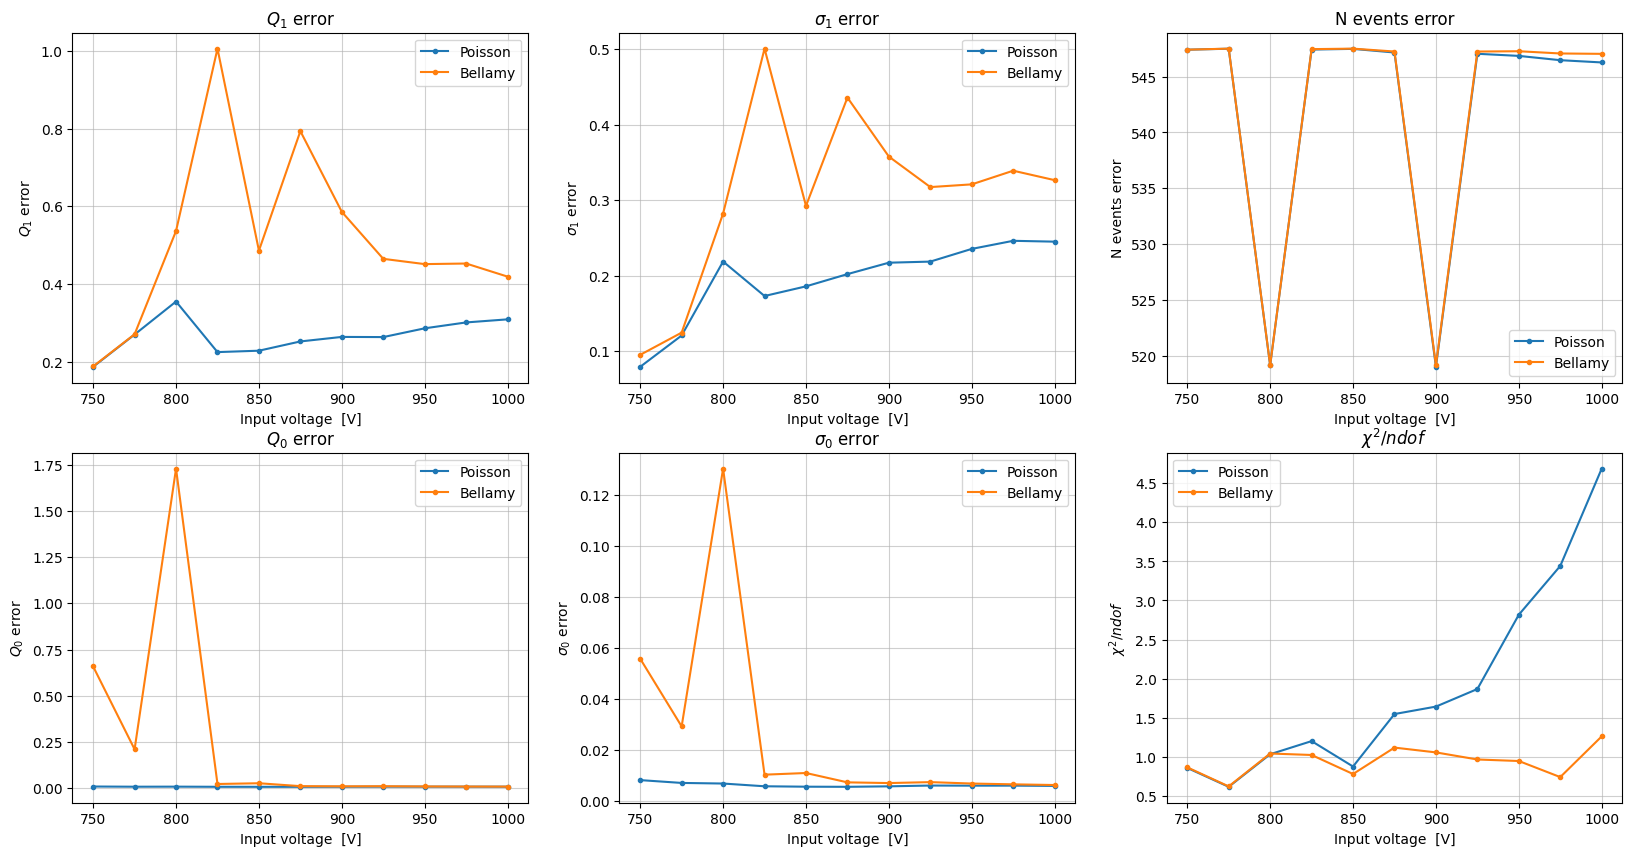

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()

xtitle = "Input voltage  [V]"
formt = 'o-'

parms = ["q1_mV_ns_err", "sigma1_mV_ns_err", "n_total_err", "q0_mV_ns_err", "sigma0_mV_ns_err", "chi2_ndof"]
ytitles = [r"$Q_1$ error", r"$\sigma_1$ error", r"N events error", r"$Q_0$ error", r"$\sigma_0$ error", r"$\chi^2 / ndof$"]

i = 0

for par, ytitle in zip(parms, ytitles):
    title = ytitle
    plot_parameter( df_poisson,    par, ax=axes[i], x="HV", xlabel=xtitle, ylabel=ytitle, title=title, label="Poisson", show_bounds=False, fmt=formt, markersize=3)
    plot_parameter( df_bellamy,    par, ax=axes[i], x="HV", xlabel=xtitle, ylabel=ytitle, title=title, label="Bellamy", show_bounds=False, fmt=formt, markersize=3)
    i+=1



## Parameter Limits

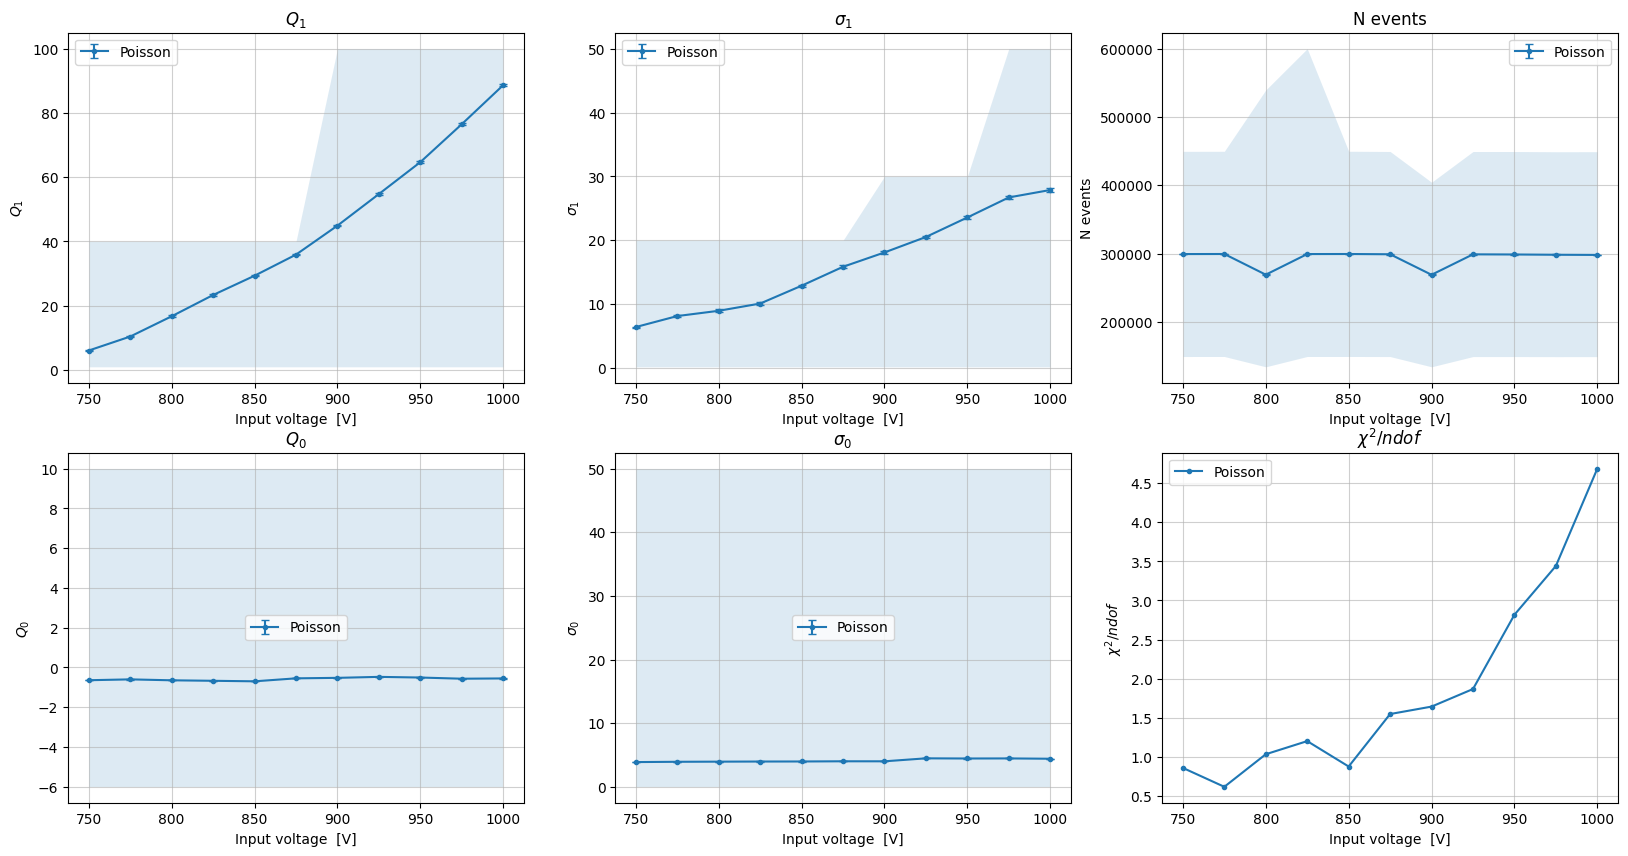

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()

xtitle = "Input voltage  [V]"
formt = 'o-'

parms = ["q1_mV_ns", "sigma1_mV_ns", "n_total", "q0_mV_ns", "sigma0_mV_ns", "chi2_ndof"]
ytitles = [r"$Q_1$", r"$\sigma_1$", r"N events", r"$Q_0$", r"$\sigma_0$", r"$\chi^2 / ndof$"]

i = 0

for par, ytitle in zip(parms, ytitles):
    title = ytitle
    plot_parameter( df_poisson, par, ax=axes[i], x="HV", xlabel=xtitle, ylabel=ytitle, title=title, label="Poisson", show_bounds=True, fmt=formt, markersize=3)
    i+=1

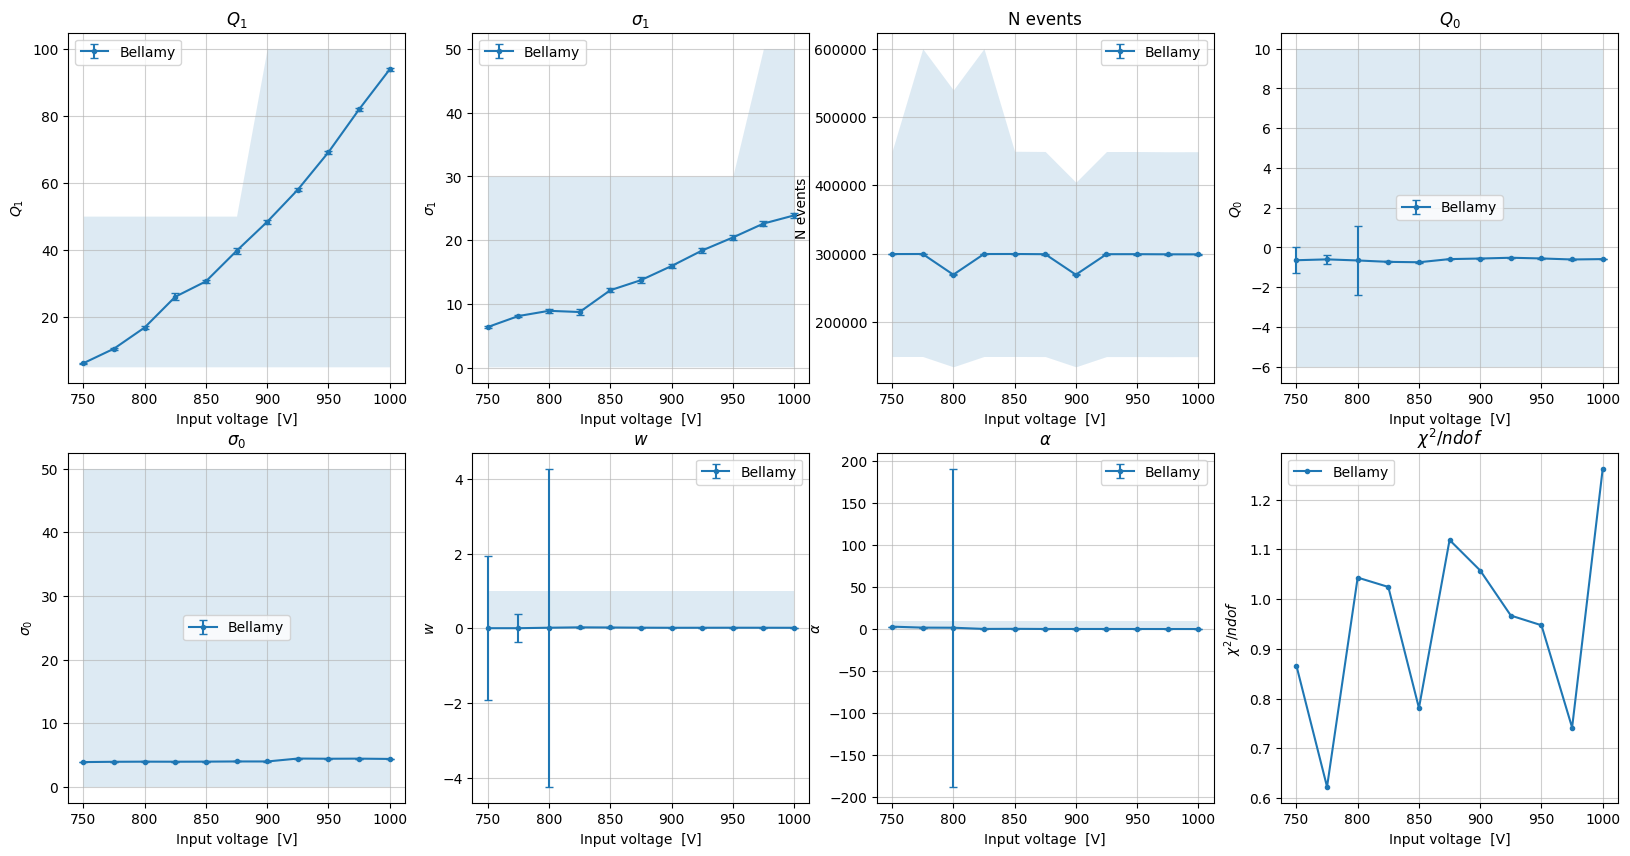

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

xtitle = "Input voltage  [V]"
formt = 'o-'


parms = ["q1_mV_ns", "sigma1_mV_ns", "n_total", "q0_mV_ns", "sigma0_mV_ns", "w", "alpha", "chi2_ndof"]
ytitles = [r"$Q_1$", r"$\sigma_1$", r"N events", r"$Q_0$", r"$\sigma_0$", r"$w$", r"$\alpha$", r"$\chi^2 / ndof$"]

i = 0

for par, ytitle in zip(parms, ytitles):
    title = ytitle
    plot_parameter( df_bellamy, par, ax=axes[i], x="HV", xlabel=xtitle, ylabel=ytitle, title=title, label="Bellamy", show_bounds=True, fmt=formt, markersize=3)
    i+=1

    

# Fit to the gain 

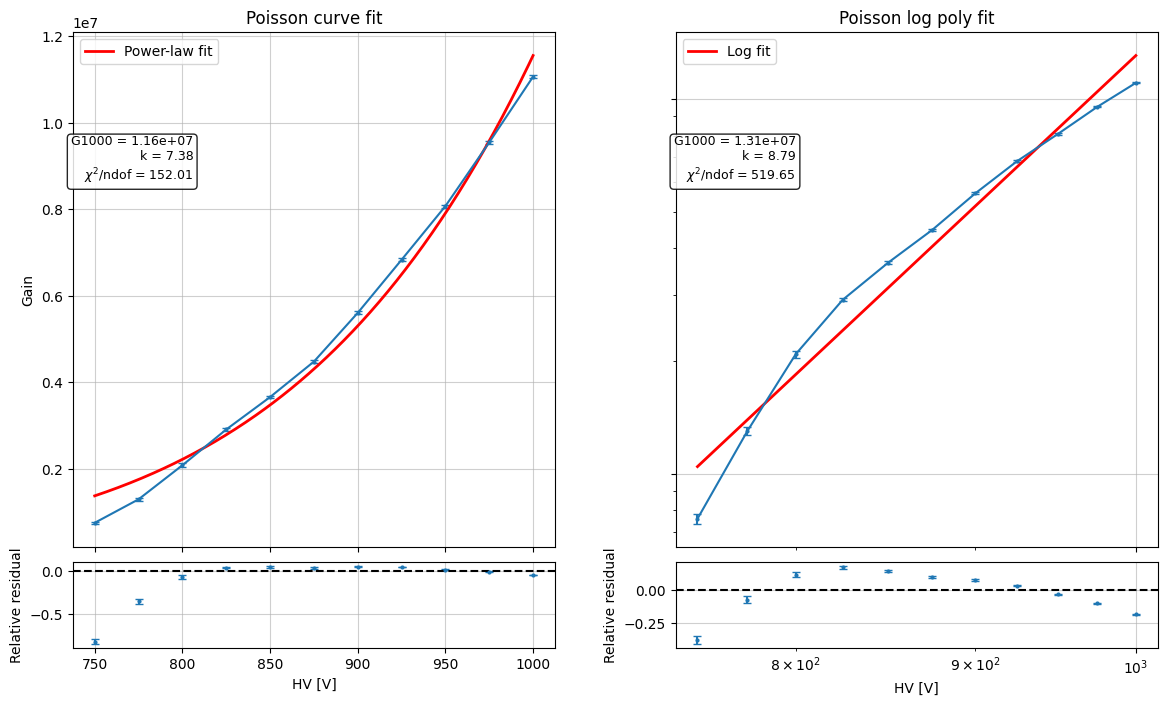

In [8]:
fit_poisson    = fit_gain_voltage(df_poisson, method="curve_fit")
fitlog_poisson = fit_gain_voltage(df_poisson, method="log_polyfit")

fig, ax, ax_res = make_fit_figure(figsize=(14, 8), height_ratios=[3, 0.5], hspace=0.05, wspace=0.25)
residual_type="relative" # "absolute", "relative", or "pull"
plot_fit_res(ax[0], ax_res[0], df_poisson, fit_poisson,    label="Power-law fit", title="Poisson curve fit",    residual_type=residual_type, plot_log=False)
plot_fit_res(ax[1], ax_res[1], df_poisson, fitlog_poisson, label="Log fit",       title="Poisson log poly fit", residual_type=residual_type, plot_log=True)
for i in range(0, 2):
    ax[i].label_outer()


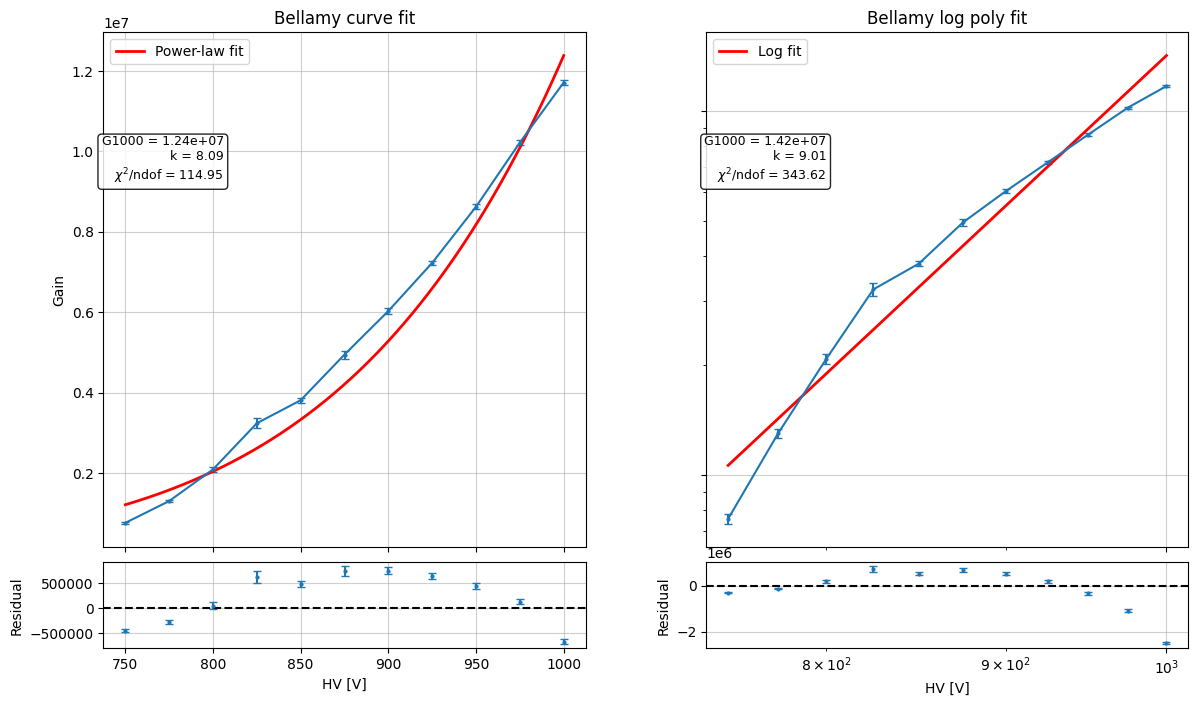

In [9]:
fit_bellamy    = fit_gain_voltage(df_bellamy, method="curve_fit")
fitlog_bellamy = fit_gain_voltage(df_bellamy, method="log_polyfit")

fig, ax, ax_res = make_fit_figure(figsize=(14, 8), height_ratios=[3, 0.5], hspace=0.05, wspace=0.25)

plot_fit_res(ax[0], ax_res[0], df_bellamy, fit_bellamy,    label="Power-law fit", title="Bellamy curve fit", plot_log=False)
plot_fit_res(ax[1], ax_res[1], df_bellamy, fitlog_bellamy, label="Log fit", title="Bellamy log poly fit", plot_log=True)
for i in range(0, 2):
    ax[i].label_outer()
